In [1]:
import os
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# ML imports
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [36]:
CONFIG = {
    # File paths
    "input_file": "/Users/n0w0f/git/n0w0f_2026/corral_modeling/corral_modeling/modelling/data/absolute_agreement_annotations_features.csv",
    "output_dir": "/Users/n0w0f/git/n0w0f_2026/corral_modeling/corral_modeling/modelling/analysis/results",
    # Target variable
    "target_column": "success",
    # Columns to exclude from features
    "exclude_columns": [
        "trace_id",
        "file_id",
        "task_id",
        "timestamp",
        "trial_id",
        "score",
        "success",  # score and success are targets/outcomes
        "model",
        "environment",
        "step_count",
        "steps_to_first_tool_call",
        "steps_to_first_error",
        "steps_to_first_positive_marker",
        "steps_to_first_negative_marker",
        "steps_to_first_planning",
        "steps_to_first_reasoning",
        "most_used_tool",
        "annotator",
        "tools_used_list"
    ],
    # Categorical columns to one-hot encode
    "categorical_columns": [
        #"annotator",
        # "model",
        # "environment",
        "agent_type",
      #  "most_used_tool",
    ],
    # Model parameters
    "test_size": 0.2,
    "random_state": 42,
    "cv_folds": 5,
    # XGBoost parameters (install with: pip install xgboost)
    "use_xgboost": True,  # Set to False if xgboost is not installed
    # Correlation thresholds
    "high_correlation_threshold": 0.8,  # For removing redundant features
    "vif_threshold": 10,  # For multicollinearity detection
    # Visualization settings
    "figure_dpi": 300,
    "figure_size": (7, 5),
    "max_features_to_plot": 30,  # Max features in importance plots
}
config = CONFIG

In [37]:
df = pd.read_csv(config["input_file"])

In [38]:
class_dist = df[config["target_column"]].value_counts()
print(f"\nClass Distribution:")
for cls, count in class_dist.items():
    pct = count / len(df) * 100
    print(f"  {cls}: {count} ({pct:.1f}%)")


Class Distribution:
  False: 284 (54.8%)
  True: 234 (45.2%)


In [39]:
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f"\nMissing values found in {(missing > 0).sum()} columns")
    # Fill missing values for categorical columns
    for col in config["categorical_columns"]:
        if col in df.columns and df[col].isnull().any():
            #print(col)
            df[col].fillna("UNKNOWN", inplace=True)


Missing values found in 1 columns


# exploratory_analysis

In [40]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

In [41]:
numeric_cols = [
            col for col in numeric_cols if col not in config["exclude_columns"]
        ]

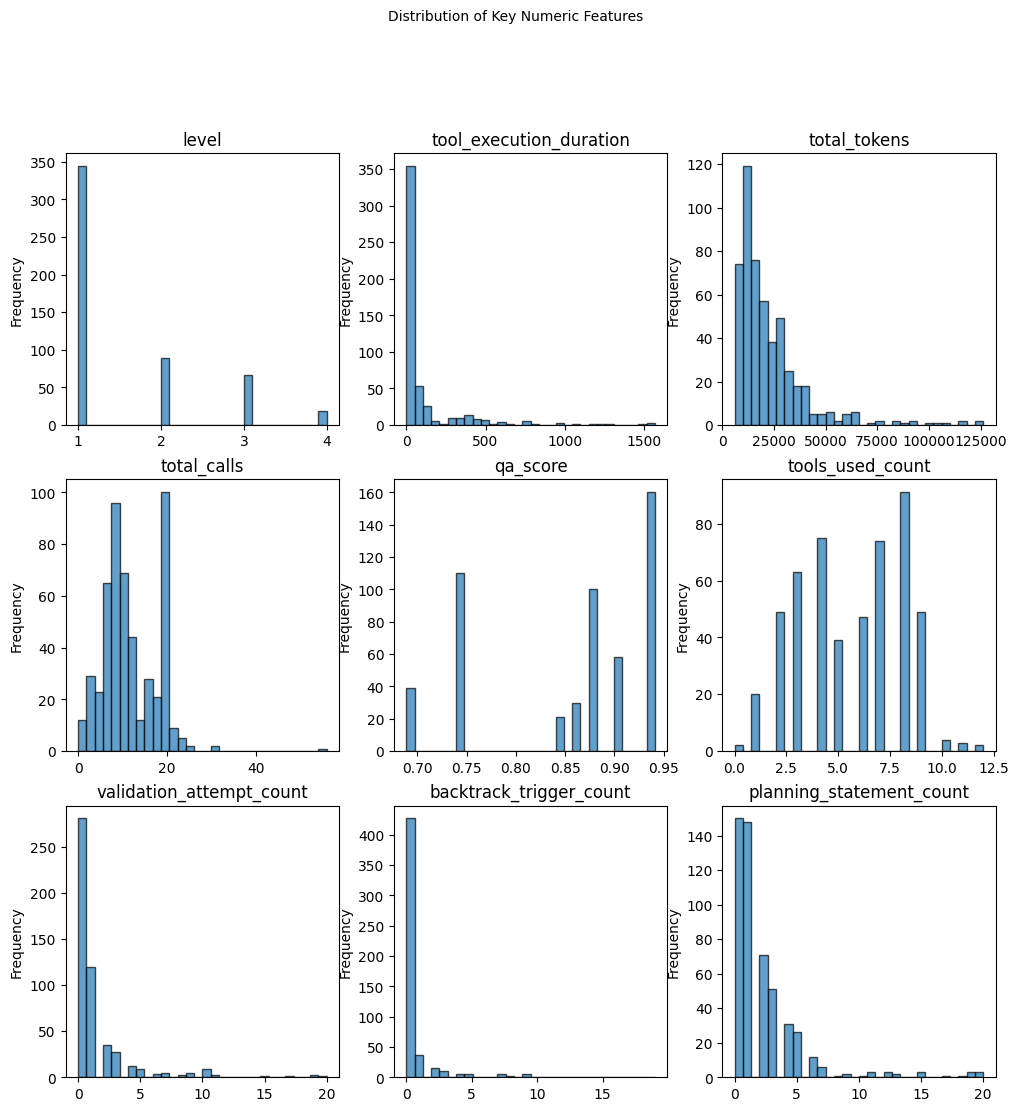

In [43]:
if len(numeric_cols) > 0:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()

    plot_cols = numeric_cols[:9]  # Plot first 9 numeric features
    plot_cols = ["level", "tool_execution_duration", "total_tokens", "total_calls" , "qa_score", "tools_used_count", "validation_attempt_count", "backtrack_trigger_count", "planning_statement_count"]
    for idx, col in enumerate(plot_cols):
        if df[col].nunique() > 1:
            axes[idx].hist(
                df[col].dropna(), bins=30, edgecolor="black", alpha=0.7
            )
            axes[idx].set_title(f"{col}")

            axes[idx].set_ylabel("Frequency")

    for idx in range(len(plot_cols), 9):
        fig.delaxes(axes[idx])

    plt.suptitle("Distribution of Key Numeric Features", fontsize=10, y=1.00)
    plt.show()



## feature_engineering

In [44]:
y = df[config["target_column"]].copy()

In [45]:
feature_cols = [
            col for col in df.columns if col not in config["exclude_columns"]
        ]
X = df[feature_cols].copy()

In [46]:
categorical_features = [
            col for col in config["categorical_columns"] if col in X.columns
        ]

In [47]:
X = pd.get_dummies(
                X, columns=categorical_features, drop_first=True
            )

In [48]:
X.columns = X.columns.str.replace(r"[\[\]<>]", "_", regex=True)

In [49]:
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
non_numeric

['has_thought_tags', 'agent_type_ToolCallingAgent']

In [50]:

# Handle any remaining non-numeric columns
if non_numeric:
    print(
        f"Label encoding {len(non_numeric)} remaining non-numeric columns..."
    )
    le = LabelEncoder()
    for col in non_numeric:
        X[col] = le.fit_transform(X[col].astype(str))

Label encoding 2 remaining non-numeric columns...


In [51]:
# Remove constant features
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
if constant_cols:
    print(f"Removing {len(constant_cols)} constant features")
    X = X.drop(columns=constant_cols)

Removing 4 constant features


In [52]:
# Handle inf and nan
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print(f"Final feature count: {len(X.columns)}")

Final feature count: 93


## correlation_analysis

In [53]:
corr_matrix = X.corr()

Text(0.5, 1.0, 'Feature Correlation Matrix')

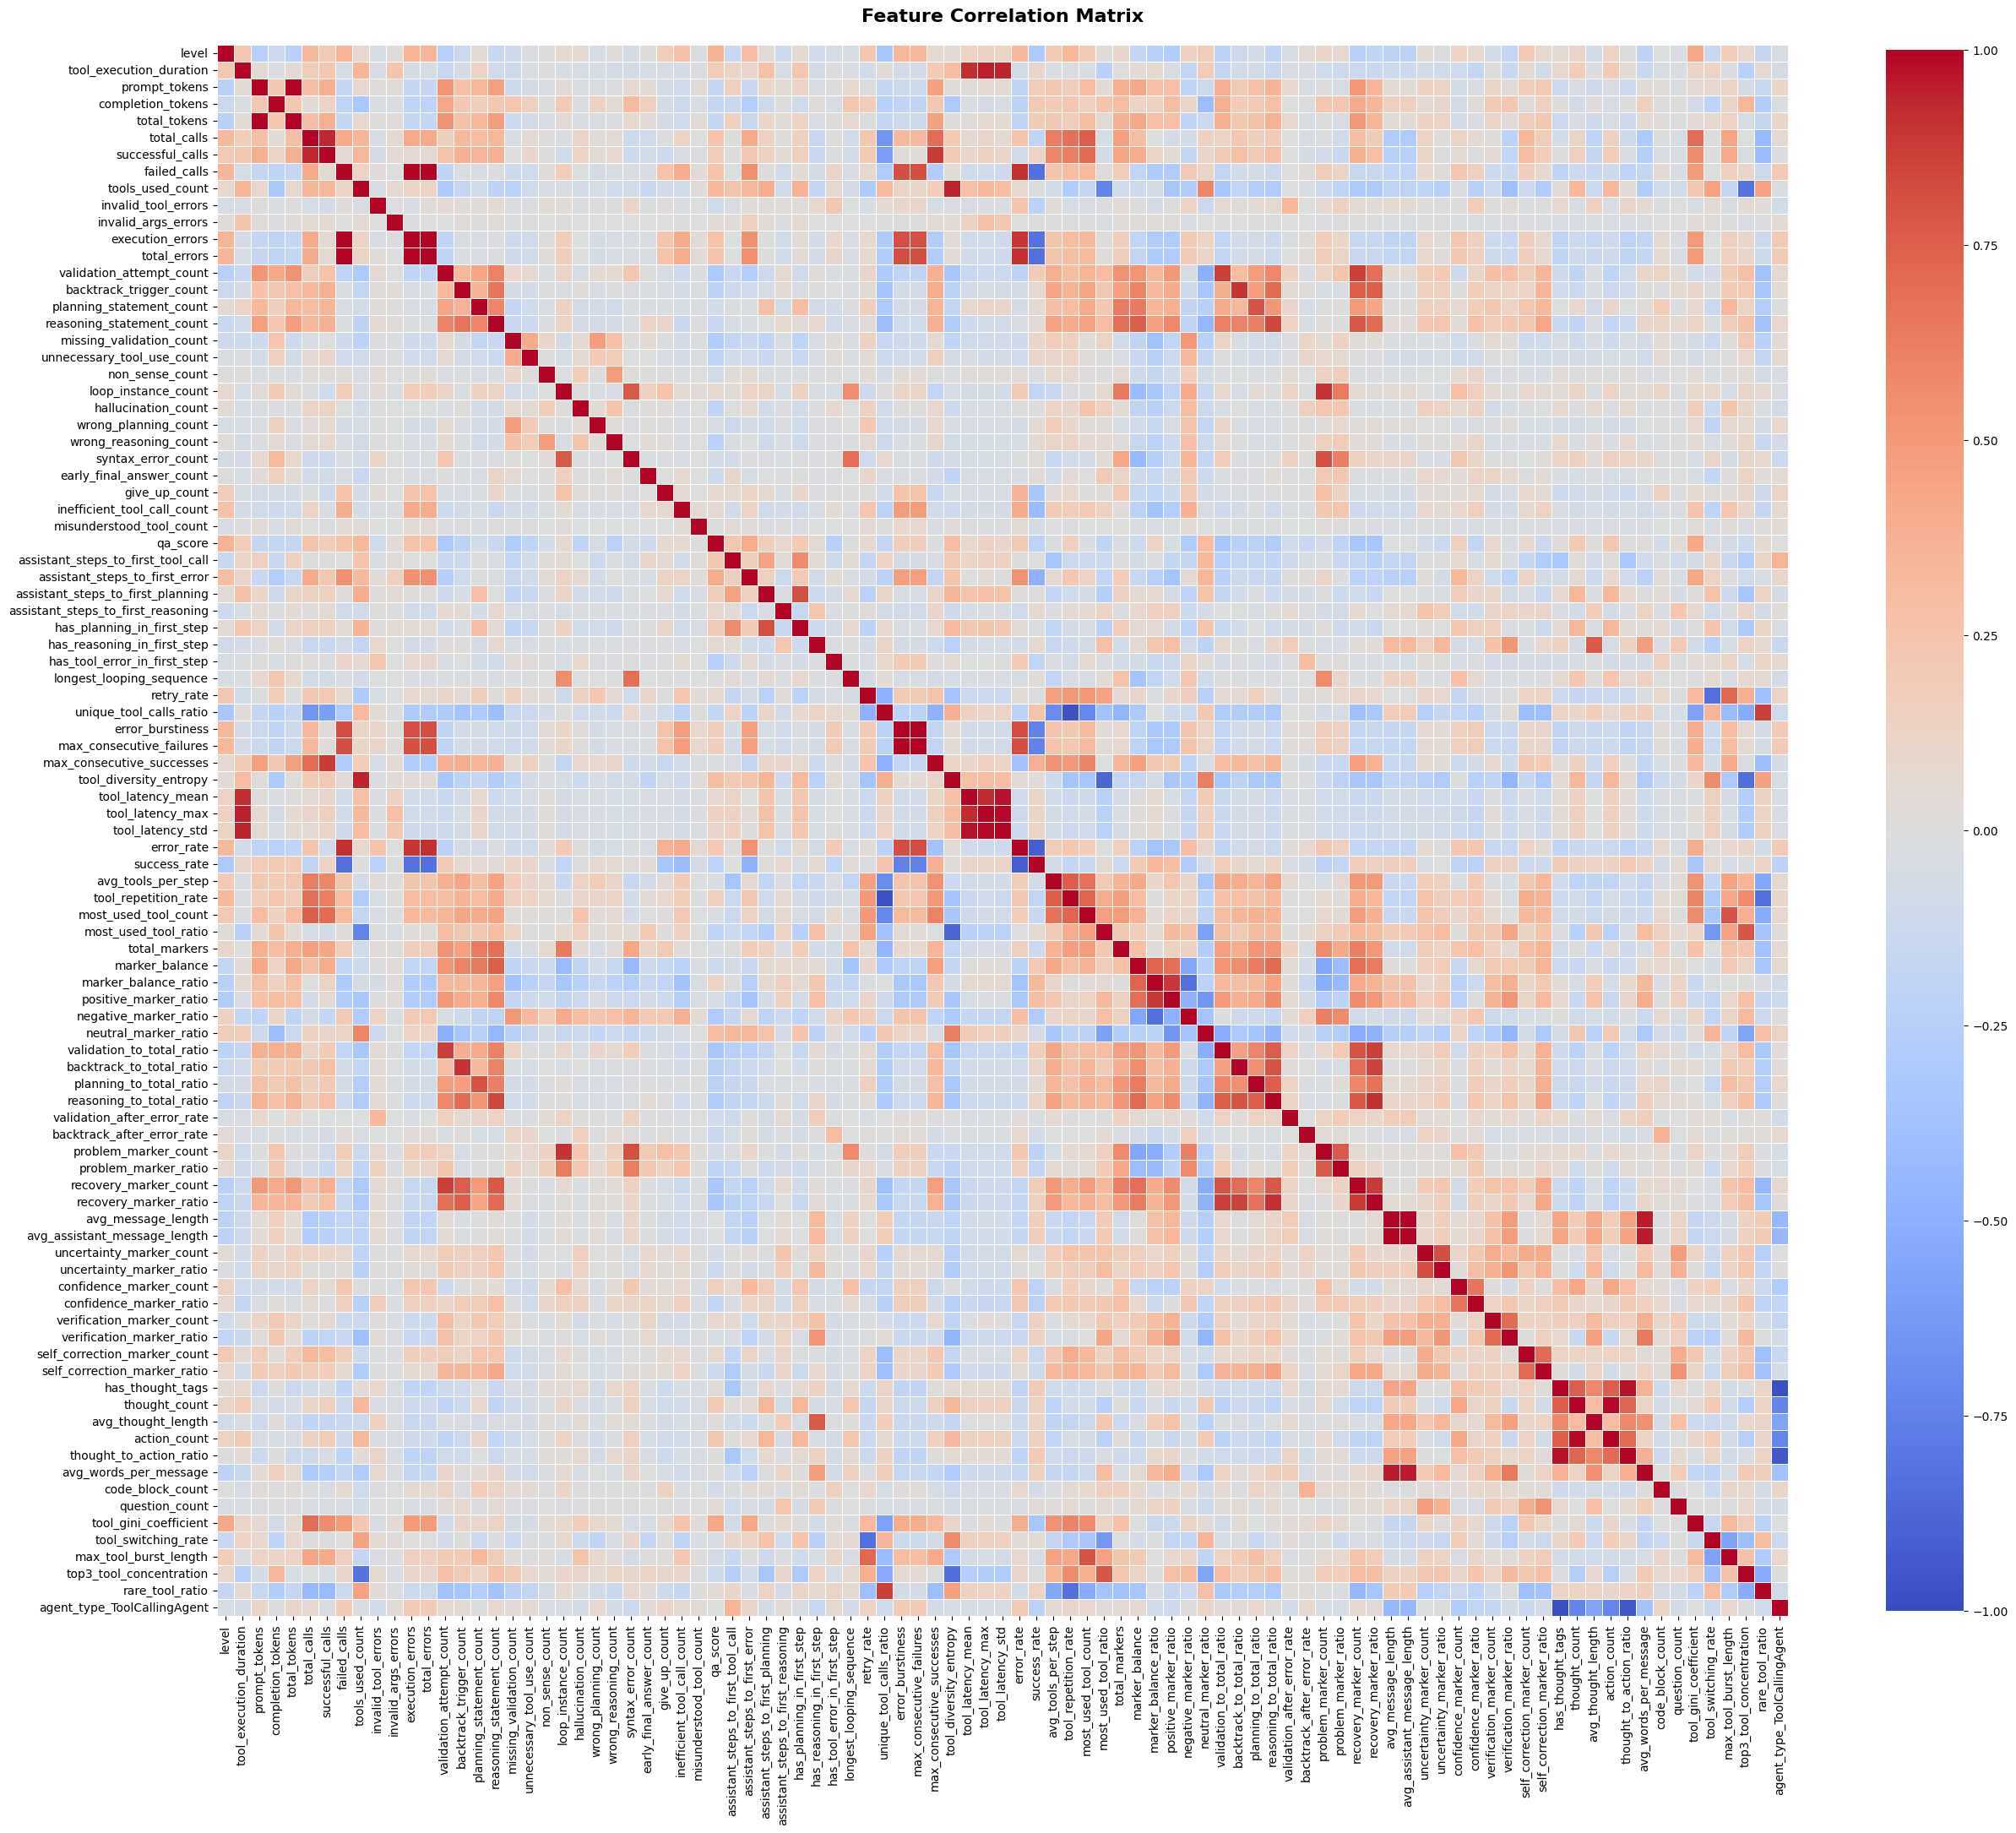

In [63]:
n_features = min(100, len(X.columns))
if len(X.columns) > n_features:
    # Select features with highest variance for visualization
    variances = X.var().sort_values(ascending=False)
    top_features = variances.head(n_features).index.tolist()
    plot_corr = corr_matrix.loc[top_features, top_features]
else:
    plot_corr = corr_matrix

fig, ax = plt.subplots(figsize=(30, 30))
sns.heatmap(
    plot_corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title(
    "Feature Correlation Matrix", fontsize=16, fontweight="bold", pad=20
    )

### High correlation features

In [64]:
threshold = config["high_correlation_threshold"]
high_corr_pairs = []

In [65]:
for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > threshold:
                    high_corr_pairs.append(
                        {
                            "Feature1": corr_matrix.columns[i],
                            "Feature2": corr_matrix.columns[j],
                            "Correlation": corr_matrix.iloc[i, j],
                        }
                    )
if high_corr_pairs:
    print(
        f"Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > {threshold})"
    )
    high_corr_df = pd.DataFrame(high_corr_pairs)

Found 59 highly correlated feature pairs (|r| > 0.8)


In [66]:
high_corr_pairs

[{'Feature1': 'tool_execution_duration',
  'Feature2': 'tool_latency_mean',
  'Correlation': np.float64(0.9146240553360389)},
 {'Feature1': 'tool_execution_duration',
  'Feature2': 'tool_latency_max',
  'Correlation': np.float64(0.9488956681530712)},
 {'Feature1': 'tool_execution_duration',
  'Feature2': 'tool_latency_std',
  'Correlation': np.float64(0.9395983782960596)},
 {'Feature1': 'prompt_tokens',
  'Feature2': 'total_tokens',
  'Correlation': np.float64(0.9998105846874661)},
 {'Feature1': 'total_calls',
  'Feature2': 'successful_calls',
  'Correlation': np.float64(0.9298318767435866)},
 {'Feature1': 'successful_calls',
  'Feature2': 'max_consecutive_successes',
  'Correlation': np.float64(0.8807043326713704)},
 {'Feature1': 'failed_calls',
  'Feature2': 'execution_errors',
  'Correlation': np.float64(0.9976551270492214)},
 {'Feature1': 'failed_calls',
  'Feature2': 'total_errors',
  'Correlation': np.float64(1.0)},
 {'Feature1': 'failed_calls',
  'Feature2': 'error_burstiness',


In [67]:
high_corr_df.to_csv("feature_feature_high_correlation.csv")

#### Feature-Target correlation

In [68]:
target_corr = pd.DataFrame(
            {
                "Feature": X.columns,
                "Correlation": [
                    pearsonr(X[col], y)[0] for col in X.columns
                ],
            }
        ).sort_values("Correlation", key=abs, ascending=False)

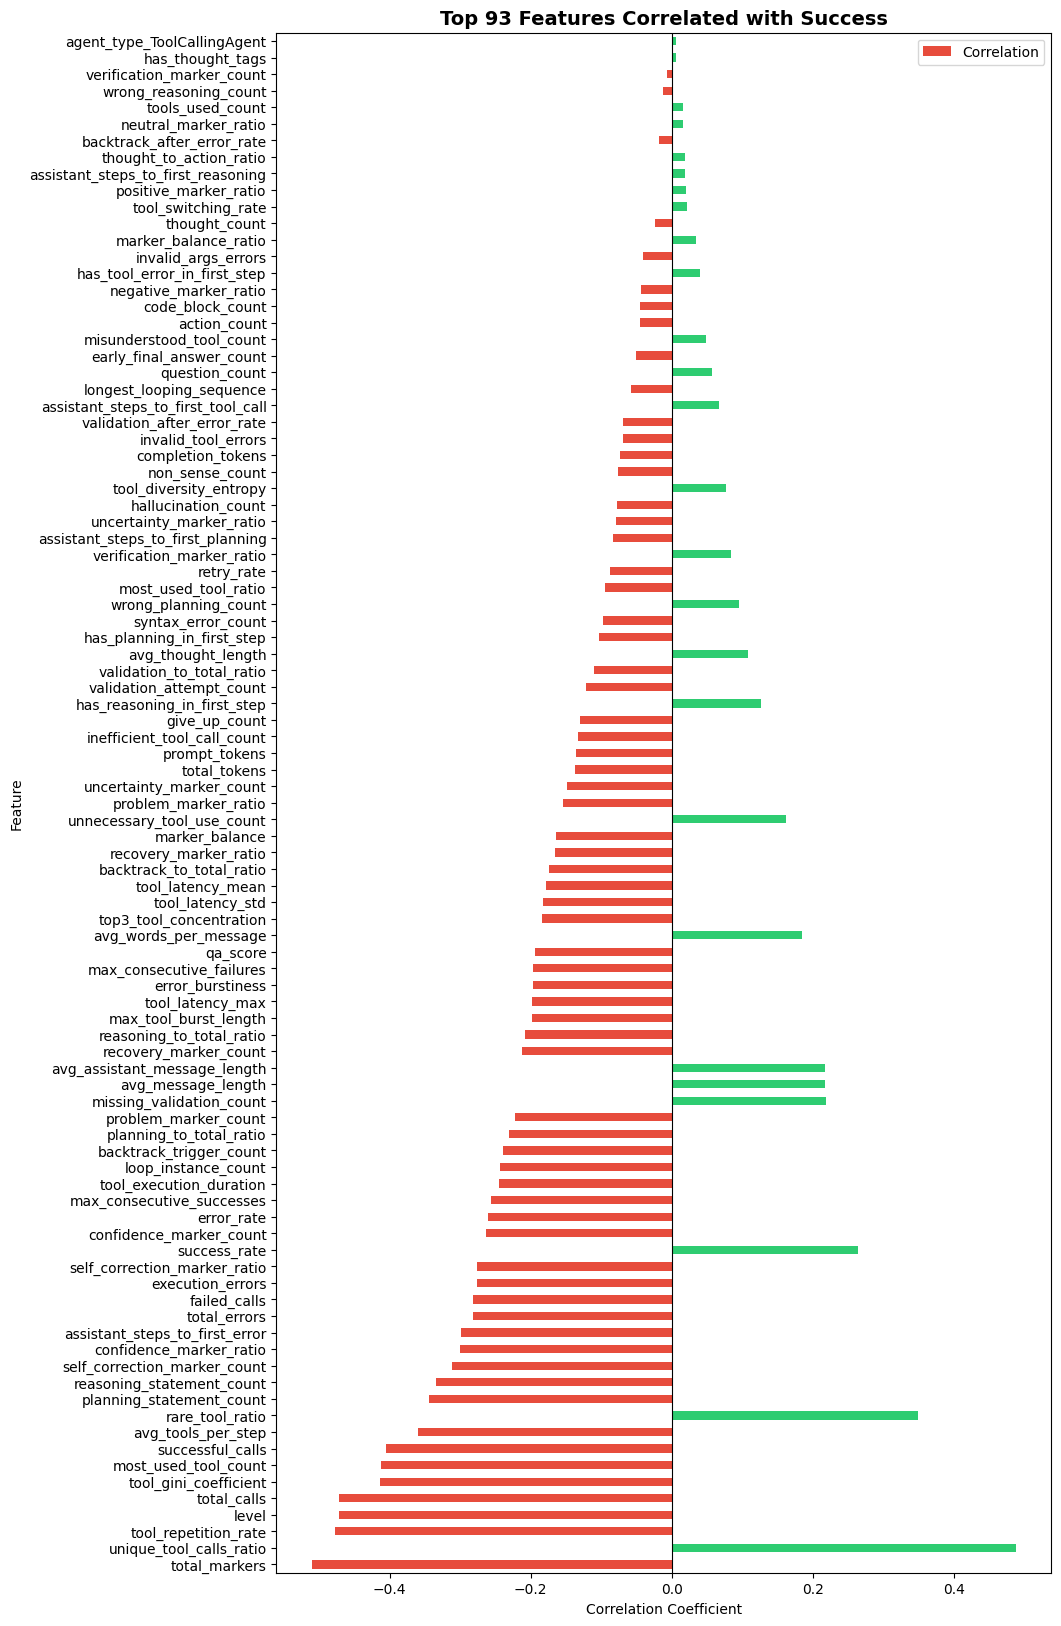

In [72]:

top_n = len(target_corr)
fig, ax = plt.subplots(figsize=(10, 20))
target_corr.head(top_n).plot(
    x="Feature",
    y="Correlation",
    kind="barh",
    ax=ax,
    color=[
        "#2ecc71" if x > 0 else "#e74c3c"
        for x in target_corr.head(top_n)["Correlation"]
    ],
)
ax.set_title(
    f"Top {top_n} Features Correlated with Success",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)


In [73]:
target_corr

,Feature,Correlation
53,total_markers,-0.510547
39,unique_tool_calls_ratio,0.488791
50,tool_repetition_rate,-0.477639
0,level,-0.472373
5,total_calls,-0.471658
...,...,...
8,tools_used_count,0.016155
23,wrong_reasoning_count,-0.011931
75,verification_marker_count,-0.006829
79,has_thought_tags,0.006778


### Clean data frame based on correlations and VIF

In [74]:
# create a copy of df , uncorrelated_df where we remove one feature from each pair in high_corr_df. 
# We select the one to be removed by looking to the correlation with target

# Create a copy of X to work with
uncorrelated_X = X.copy()

# Track features to remove
features_to_remove = set()

# For each highly correlated pair, remove the feature with lower target correlation
for _, row in high_corr_df.iterrows():
    feat1 = row['Feature1']
    feat2 = row['Feature2']
    
    # Skip if either feature is already marked for removal
    if feat1 in features_to_remove or feat2 in features_to_remove:
        continue
    
    # Get target correlations for both features
    corr1 = target_corr[target_corr['Feature'] == feat1]['Correlation'].values
    corr2 = target_corr[target_corr['Feature'] == feat2]['Correlation'].values
    
    # Only proceed if both features exist in target_corr
    if len(corr1) > 0 and len(corr2) > 0:
        corr1 = abs(corr1[0])
        corr2 = abs(corr2[0])
        
        # Remove the feature with lower absolute correlation with target
        if corr1 < corr2:
            features_to_remove.add(feat1)
        else:
            features_to_remove.add(feat2)

# Remove the selected features
uncorrelated_X = uncorrelated_X.drop(columns=list(features_to_remove))

print(f"Removed {len(features_to_remove)} features due to high correlation")
print(f"Features removed: {sorted(features_to_remove)}")
print(f"Remaining features: {uncorrelated_X.shape[1]}")

Removed 32 features due to high correlation
Features removed: ['agent_type_ToolCallingAgent', 'assistant_steps_to_first_planning', 'avg_assistant_message_length', 'avg_words_per_message', 'backtrack_to_total_ratio', 'error_burstiness', 'error_rate', 'execution_errors', 'has_thought_tags', 'marker_balance_ratio', 'max_consecutive_failures', 'planning_to_total_ratio', 'positive_marker_ratio', 'problem_marker_count', 'prompt_tokens', 'rare_tool_ratio', 'reasoning_to_total_ratio', 'recovery_marker_ratio', 'success_rate', 'successful_calls', 'thought_count', 'tool_diversity_entropy', 'tool_latency_max', 'tool_latency_mean', 'tool_latency_std', 'tool_repetition_rate', 'tool_switching_rate', 'tools_used_count', 'total_errors', 'uncertainty_marker_ratio', 'validation_attempt_count', 'validation_to_total_ratio']
Remaining features: 61


In [75]:
uncorrelated_matrix = uncorrelated_X.corr()

Text(0.5, 1.0, 'Feature Correlation Matrix')

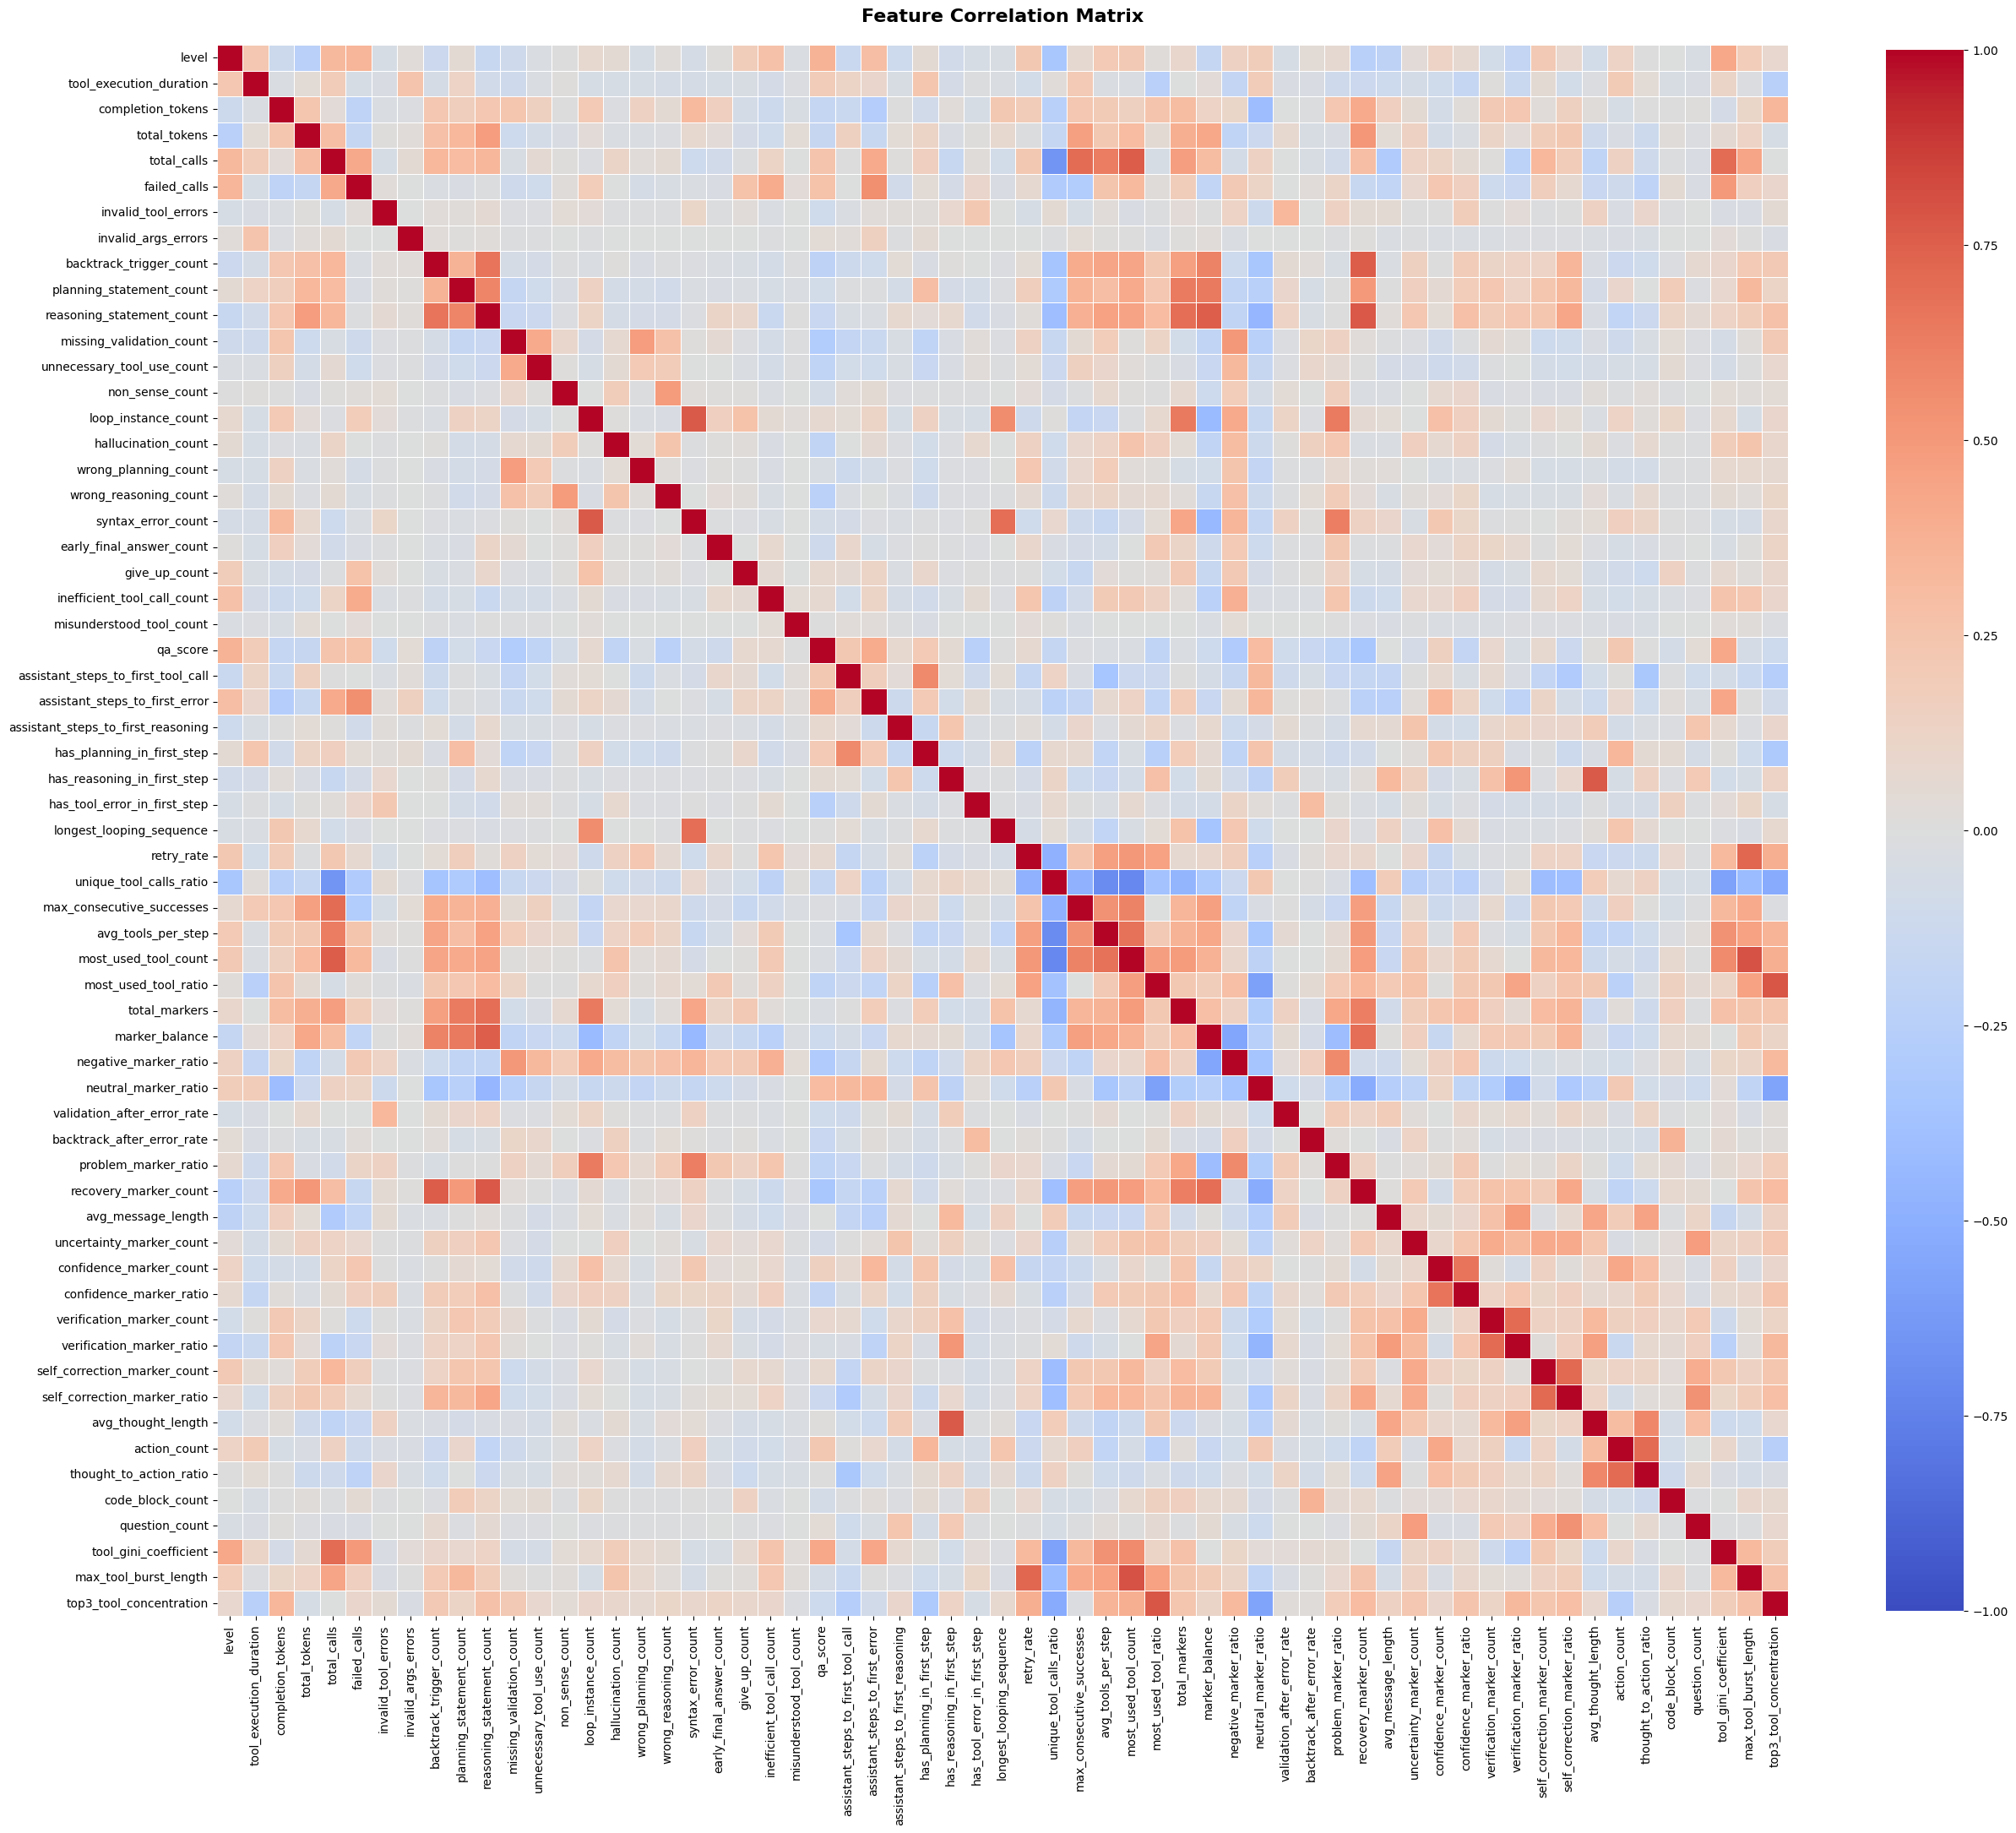

In [76]:
n_features = min(100, len(uncorrelated_X.columns))
if len(uncorrelated_X.columns) > n_features:
    # Select features with highest variance for visualization
    variances = uncorrelated_X.var().sort_values(ascending=False)
    top_features = variances.head(n_features).index.tolist()
    plot_corr = uncorrelated_matrix.loc[top_features, top_features]
else:
    plot_corr = uncorrelated_matrix

fig, ax = plt.subplots(figsize=(30, 30))
sns.heatmap(
    plot_corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title(
    "Feature Correlation Matrix", fontsize=16, fontweight="bold", pad=20
    )

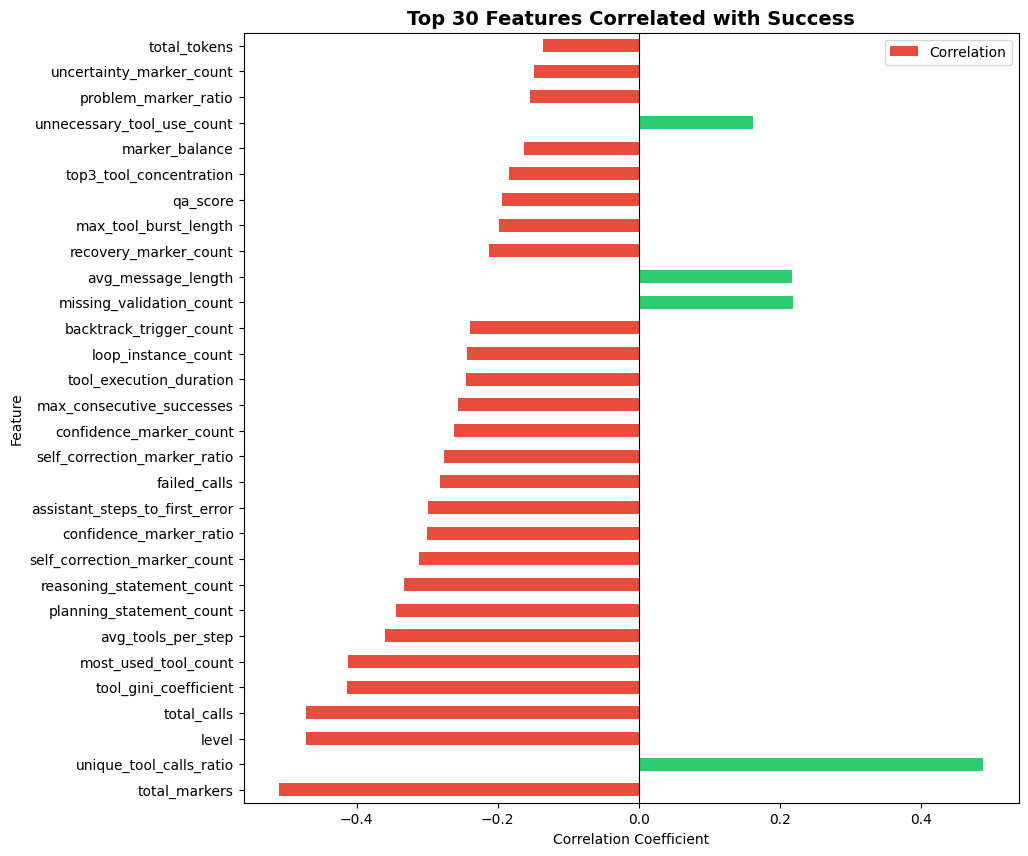

In [81]:
target_corr = pd.DataFrame(
            {
                "Feature": uncorrelated_X.columns,
                "Correlation": [
                    pearsonr(uncorrelated_X[col], y)[0] for col in uncorrelated_X.columns
                ],
            }
        ).sort_values("Correlation", key=abs, ascending=False)

top_n = int(len(target_corr)/2)
fig, ax = plt.subplots(figsize=(10, 10))
target_corr.head(top_n).plot(
    x="Feature",
    y="Correlation",
    kind="barh",
    ax=ax,
    color=[
        "#2ecc71" if x > 0 else "#e74c3c"
        for x in target_corr.head(top_n)["Correlation"]
    ],
)
ax.set_title(
    f"Top {top_n} Features Correlated with Success",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)


### Train linear model

In [82]:
X_train, X_test, y_train, y_test = train_test_split(uncorrelated_X, y, test_size=config["test_size"],
            random_state=config["random_state"],
            stratify=y,)

In [83]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
results = {}
model = LogisticRegression(
                random_state=config["random_state"],
                max_iter=1000,
                class_weight="balanced",
            )
cv = StratifiedKFold(
        n_splits=config["cv_folds"],
        shuffle=True,
        random_state=config["random_state"],
    )

X_train_use = X_train_scaled 
X_test_use = X_test_scaled 

# Cross-validation
cv_scores = cross_val_score(
    model, X_train_use, y_train, cv=cv, scoring="f1", n_jobs=-1
)

# Train on full training set
model.fit(X_train_use, y_train)

# Predictions
y_pred = model.predict(X_test_use)
y_pred_proba = model.predict_proba(X_test_use)[:, 1]

# Metrics
results= {
    "model": model,
    "cv_scores": cv_scores,
    "cv_mean": cv_scores.mean(),
    "cv_std": cv_scores.std(),
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_pred_proba),
    "y_pred": y_pred,
    "y_pred_proba": y_pred_proba,
    "X_test": X_test_use,
}

print(
    f"  CV F1 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})"
)
print(f"  Test Accuracy: {results['accuracy']:.4f}")
print(f"  Test F1 Score: {results['f1']:.4f}")
print(f"  Test ROC-AUC: {results['roc_auc']:.4f}")

  CV F1 Score: 0.8501 (+/- 0.0379)
  Test Accuracy: 0.8750
  Test F1 Score: 0.8571
  Test ROC-AUC: 0.9507


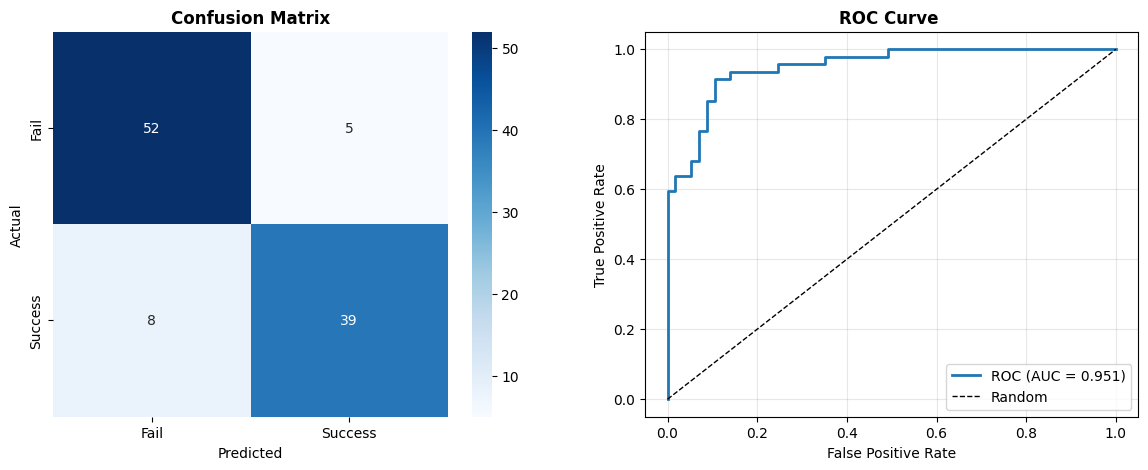

In [84]:

# Confusion Matrix
cm = confusion_matrix(y_test, results["y_pred"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Fail", "Success"],
    yticklabels=["Fail", "Success"],
)
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, results["y_pred_proba"])
axes[1].plot(
    fpr, tpr, linewidth=2, label=f'ROC (AUC = {results["roc_auc"]:.3f})'
)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve ", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

#### Feature important analysis

In [85]:
importances = np.abs(model.coef_[0])

In [88]:
feature_names = uncorrelated_X.columns.to_list()

Computing SHAP values for 104 samples with 61 features...
Using LinearExplainer for Logistic Regression...
SHAP values computed. Shape: (104, 61)


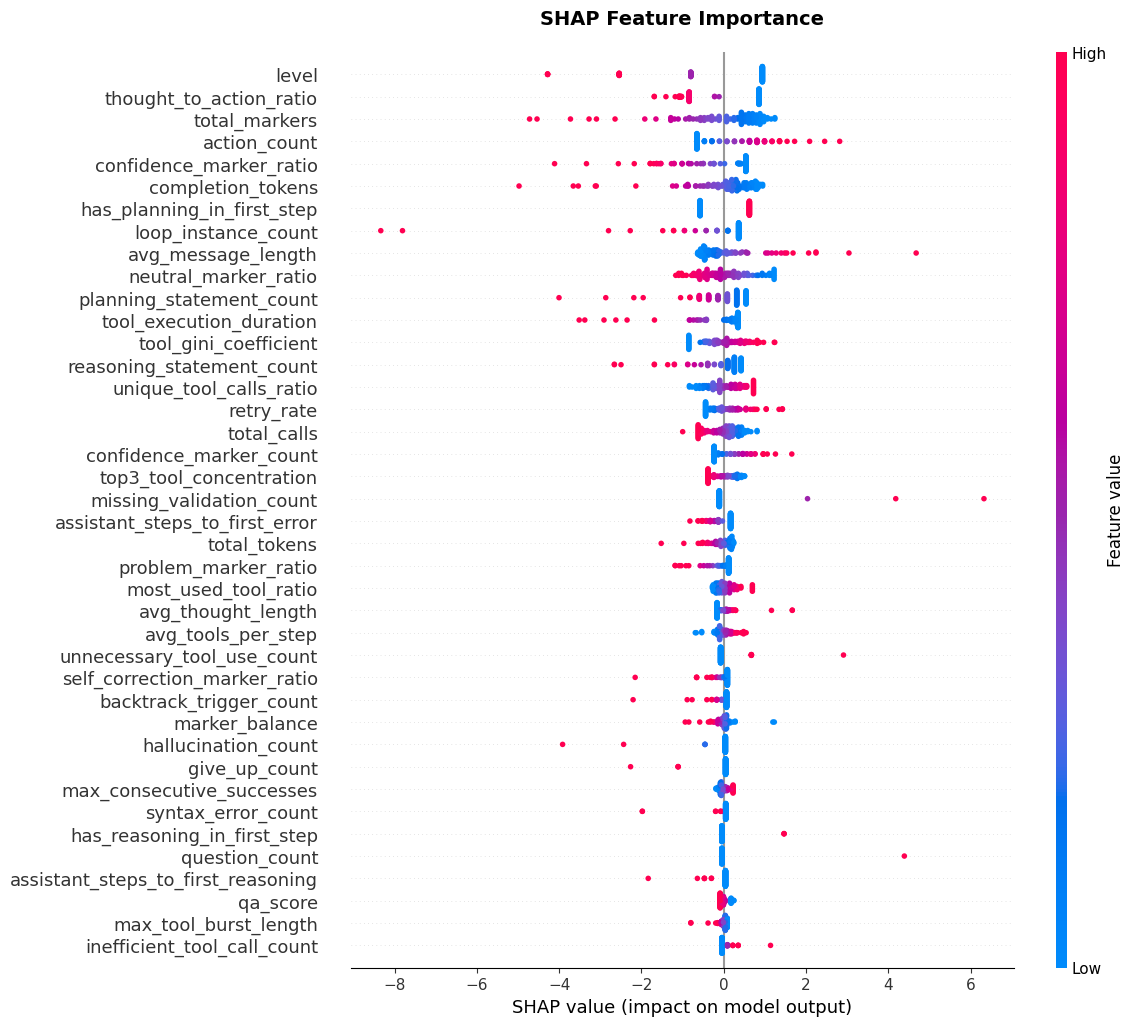

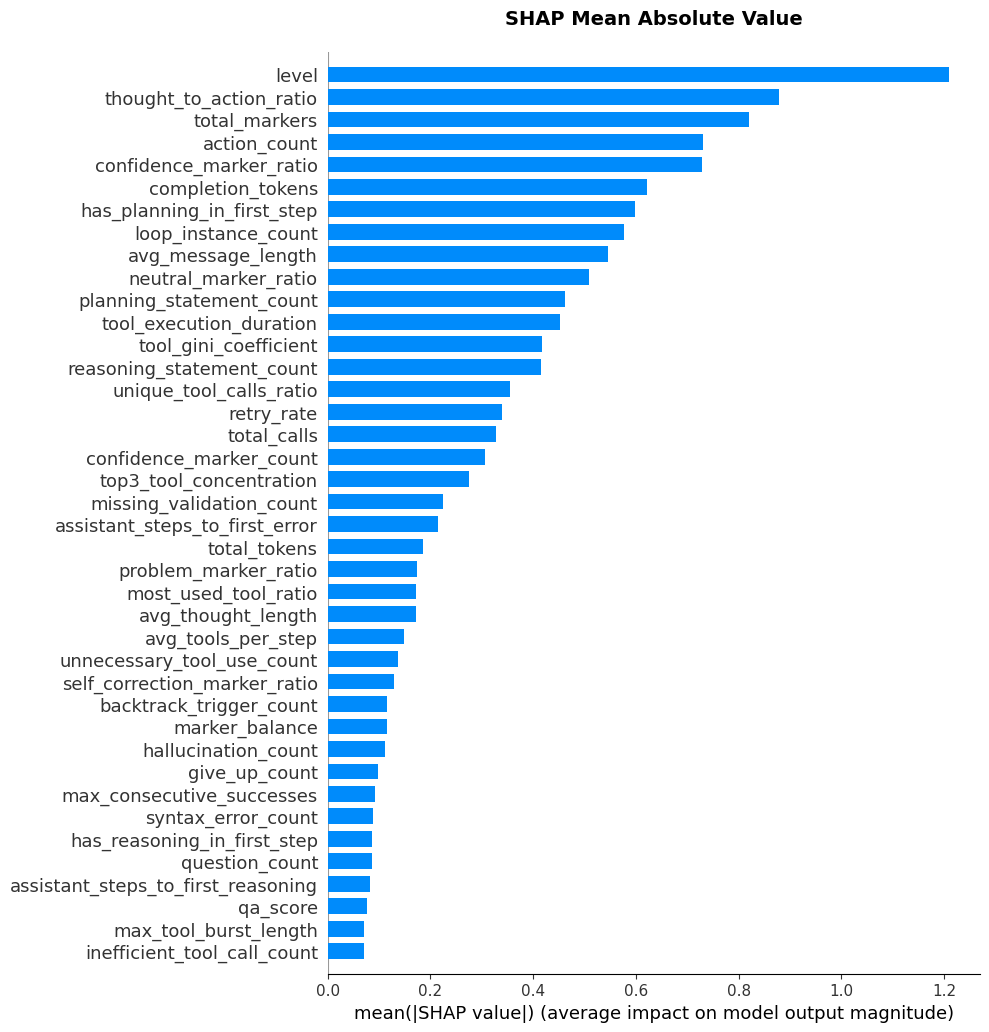

In [91]:
import shap
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# # Sample data if too large
# if len(X_test_df) > 100:
#     sample_idx = np.random.choice(len(X_test_df), 100, replace=False)
#     X_shap = X_test_df.iloc[sample_idx].copy()
# else:
X_shap = X_test_df.copy()

print(
    f"Computing SHAP values for {len(X_shap)} samples with {len(X_shap.columns)} features..."
)


print("Using LinearExplainer for Logistic Regression...")

# Need to scale the data for Logistic Regression
X_shap_scaled = scaler.transform(X_shap)

# Use LinearExplainer which is faster and more appropriate
explainer = shap.LinearExplainer(
    model, X_shap_scaled, feature_names=feature_names
)
shap_values = explainer.shap_values(X_shap_scaled)

# For display, we still want to show original (unscaled) feature values
# But use the SHAP values from the scaled model

print(f"SHAP values computed. Shape: {shap_values.shape}")

# Summary plot (beeswarm) - shows top 20 features
fig = plt.figure(figsize=(12, 15))
shap.summary_plot(
    shap_values,
    X_shap,  # Use unscaled data for display
    feature_names=feature_names,
    show=False,
    max_display=40,
    plot_size=(12, 10),
)
plt.title(
    f"SHAP Feature Importance",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.show()


# Bar plot - shows mean absolute SHAP values
fig = plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_shap,  # Use unscaled data for display
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    max_display=40,
    plot_size=(10, 10),
)
plt.title(
    f"SHAP Mean Absolute Value",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.show()

In [ ]:
import shap
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# # Sample data if too large
# if len(X_test_df) > 100:
#     sample_idx = np.random.choice(len(X_test_df), 100, replace=False)
#     X_shap = X_test_df.iloc[sample_idx].copy()
# else:
X_shap = X_test_df.copy()

print(
    f"Computing SHAP values for {len(X_shap)} samples with {len(X_shap.columns)} features..."
)


print("Using LinearExplainer for Logistic Regression...")

# Need to scale the data for Logistic Regression
X_shap_scaled = scaler.transform(X_shap)

# Use LinearExplainer which is faster and more appropriate
explainer = shap.LinearExplainer(
    model, X_shap_scaled, feature_names=feature_names
)
shap_values = explainer.shap_values(X_shap_scaled)

# For display, we still want to show original (unscaled) feature values
# But use the SHAP values from the scaled model

print(f"SHAP values computed. Shape: {shap_values.shape}")

# Summary plot (beeswarm) - shows top 20 features
fig = plt.figure(figsize=(12, 15))
shap.summary_plot(
    shap_values,
    X_shap,  # Use unscaled data for display
    feature_names=feature_names,
    show=False,
    max_display=40,
    plot_size=(12, 10),
)
plt.title(
    f"SHAP Feature Importance",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.show()


# Bar plot - shows mean absolute SHAP values
fig = plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_shap,  # Use unscaled data for display
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    max_display=40,
    plot_size=(10, 10),
)
plt.title(
    f"SHAP Mean Absolute Value",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.show()

In [ ]:
uncorrelated_X.columns

In [ ]:
vif_features = len(uncorrelated_X.columns)
X_vif = uncorrelated_X[target_corr.head(vif_features)["Feature"]].copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]
vif_data = vif_data.sort_values("VIF", ascending=False)

high_vif = vif_data[vif_data["VIF"] > config["vif_threshold"]]
if len(high_vif) > 0:
    print(
        f"Found {len(high_vif)} features with VIF > {config['vif_threshold']}"
    )

# Plot VIF
fig, ax = plt.subplots(figsize=(10, 8))
vif_data.plot(
    x="Feature", y="VIF", kind="barh", ax=ax, color="steelblue", legend=False
)
ax.axvline(
    x=config["vif_threshold"],
    color="red",
    linestyle="--",
    label=f'Threshold ({config["vif_threshold"]})',
)
ax.set_title(
    "Variance Inflation Factor (VIF) - Multicollinearity Check",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("VIF Score")
ax.legend()